# Regression Analysis: Farm, Cat, Economic, and News Data

This notebook provides an exploratory regression analysis based on the merged `farm_cat_eco_news` dataset for Australia `2017-2022`.  
The goal is to examine whether cat-related, media-related, and economic indicators help explain variation in key farm outcomes.

The analysis uses a small set of selected variables from four dimensions:

- **farm variables** — such as `sheep_flock` and `lambs`;
- **cat variables** — such as `cats_occurrence_total` and `cats_forest`;
- **news variables** — such as `article_count` and `tone_weighted`;
- **economic variables** — such as `eco_cost_total`.

In this notebook, we:
1. inspect and treat missing values;
2. review descriptive statistics and correlations;
3. compare several small regression specifications;
4. select the main exploratory model;
5. check the standard linear regression assumptions;
6. interpret the results with caution given the very limited sample size.

TW: Because the dataset contains only 6 annual observations, all regression results in this notebook should be treated as exploratory rather than conclusive.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro
from ydata_profiling import ProfileReport

c:\Users\Ксения\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [37]:
%matplotlib inline

In [7]:
farm_cat_eco_news = pd.read_csv("../datasets/farm_cat_eco_news.csv")

In [49]:
profile = ProfileReport(farm_cat_eco_news, title="Profiling Report", explorative=True)
profile.to_file("../datasets/reports/report_farm_cat_eco_news.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 71.41it/s]


In [6]:
farm_cat_eco_news.shape

(6, 28)

### Missing values

In [ ]:
# Columns where missing values likely mean absence of recorded costs/measures
zero_fill_cols = [
    'eco_cost_total',
    'eco_cost_cat_only',
    'eco_cost_cat_plus_other',
    'eco_type_damage_loss',
    'eco_type_control_prevention',
    'eco_type_control_medical_care',
    'eco_type_control_education',
    'eco_type_control',
    'eco_type_eradication',
    'eco_type_prevention',
    'eco_sector_health',
    'eco_sector_environment',
    'eco_sector_authorities_stakeholders',
    'eco_sector_agriculture'
]

# Replace NaN with 0 only in these columns
farm_cat_eco_news[zero_fill_cols] = farm_cat_eco_news[zero_fill_cols].fillna(0)

# Re-check missing values
remaining_missing = farm_cat_eco_news.isna().sum().sort_values(ascending=False)
remaining_missing = remaining_missing[remaining_missing > 0]

print("Remaining missing values")
display(remaining_missing)

Remaining missing values after selective filling:


Series([], dtype: int64)

Missing values were found only in economic cost subcategories and sector/type-specific cost variables.  
Since these variables represent the absence of recorded costs or measures in a given year, missing values were replaced with zeros.  
Core farm, cat, and news variables were left unchanged.

### Creating Linear Regression Models

In [26]:
candidate_vars = [
    'sheep_flock',
    'lambs',
    'cats_occurrence_total',
    'cats_forest',
    'article_count',
    'tone_weighted',
    'volume_intensity',
    'eco_cost_total'
]

corr_candidates = farm_cat_eco_news[candidate_vars].corr(method='pearson')
display(corr_candidates.round(3))

,sheep_flock,lambs,cats_occurrence_total,cats_forest,article_count,tone_weighted,volume_intensity,eco_cost_total
sheep_flock,1.000,0.863,-0.314,-0.612,0.537,0.475,0.422,-0.538
lambs,0.863,1.000,-0.674,-0.873,0.164,0.585,0.050,-0.558
cats_occurrence_total,-0.314,-0.674,1.000,0.871,0.176,-0.515,0.272,0.606
cats_forest,-0.612,-0.873,0.871,1.000,0.176,-0.401,0.312,0.715
article_count,0.537,0.164,0.176,0.176,1.000,0.392,0.986,-0.106
tone_weighted,0.475,0.585,-0.515,-0.401,0.392,1.000,0.365,-0.474
volume_intensity,0.422,0.050,0.272,0.312,0.986,0.365,1.000,0.036
eco_cost_total,-0.538,-0.558,0.606,0.715,-0.106,-0.474,0.036,1.000


In [17]:
corr_with_sheep_flock = corr_candidates['sheep_flock'].sort_values(ascending=False)
print("Correlations with sheep_flock:")
display(corr_with_sheep_flock)

Correlations with sheep_flock:


sheep_flock              1.000000
lambs                    0.862511
article_count            0.536569
tone_weighted            0.475059
volume_intensity         0.421773
cats_occurrence_total   -0.313845
cats_forest             -0.611908
Name: sheep_flock, dtype: float64

In [18]:
corr_with_lambs = corr_candidates['lambs'].sort_values(ascending=False)
print("Correlations with lambs:")
display(corr_with_lambs)

Correlations with lambs:


lambs                    1.000000
sheep_flock              0.862511
tone_weighted            0.584803
article_count            0.163530
volume_intensity         0.050359
cats_occurrence_total   -0.673864
cats_forest             -0.872516
Name: lambs, dtype: float64

In [ ]:
# Define candidate model specifications
model_specs = {
    'M1': {'target': 'sheep_flock', 'predictors': ['cats_occurrence_total', 'article_count']},
    'M2': {'target': 'sheep_flock', 'predictors': ['cats_occurrence_total', 'tone_weighted']},
    'M3': {'target': 'sheep_flock', 'predictors': ['cats_occurrence_total', 'eco_cost_total']},
    'M4': {'target': 'sheep_flock', 'predictors': ['cats_forest', 'article_count']},
    'M5': {'target': 'sheep_flock', 'predictors': ['cats_forest', 'tone_weighted']},
    'M6': {'target': 'sheep_flock', 'predictors': ['cats_forest', 'eco_cost_total']},
    'M7': {'target': 'lambs', 'predictors': ['cats_occurrence_total', 'tone_weighted']},
    'M8': {'target': 'lambs', 'predictors': ['cats_occurrence_total', 'eco_cost_total']},
    'M9': {'target': 'lambs', 'predictors': ['cats_forest', 'tone_weighted']},
    'M10': {'target': 'lambs', 'predictors': ['cats_forest', 'eco_cost_total']}
}

# Fit all models
fitted_models = {}
comparison_rows = []

for model_name, spec in model_specs.items():
    target = spec['target']
    predictors = spec['predictors']
    
    cols = ['year', target] + predictors
    model_df = farm_cat_eco_news[cols].dropna().copy()
    
    X = sm.add_constant(model_df[predictors])
    y = model_df[target]
    
    model = sm.OLS(y, X).fit()
    fitted_models[model_name] = {
        'model': model,
        'data': model_df,
        'target': target,
        'predictors': predictors
    }
    
    row = {
        'model': model_name,
        'formula': f"{target} ~ {' + '.join(predictors)}",
        'n_obs': int(model.nobs),
        'R_squared': model.rsquared,
        'Adj_R_squared': model.rsquared_adj,
        'F_pvalue': model.f_pvalue,
        'AIC': model.aic,
        'BIC': model.bic
    }
    
    # Add coefficients and p-values
    for var in ['const'] + predictors:
        row[f'coef_{var}'] = model.params.get(var, None)
        row[f'pval_{var}'] = model.pvalues.get(var, None)
    
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)

# Sort by adjusted R^2 first, then by AIC
comparison_df = comparison_df.sort_values(
    by=['Adj_R_squared', 'R_squared'],
    ascending=False
).reset_index(drop=True)

display(comparison_df.round(4))

,model,formula,n_obs,R_squared,Adj_R_squared,F_pvalue,AIC,BIC,coef_const,pval_const,coef_cats_occurrence_total,pval_cats_occurrence_total,coef_article_count,pval_article_count,coef_tone_weighted,pval_tone_weighted,coef_eco_cost_total,pval_eco_cost_total,coef_cats_forest,pval_cats_forest
0,M9,lambs ~ cats_forest + tone_weighted,6,0.8269,0.7115,0.0720,97.2083,96.5836,15426.9763,0.0029,NaN,NaN,NaN,NaN,909.1203,0.3646,NaN,NaN,-3.6821,0.0626
1,M4,sheep_flock ~ cats_forest + article_count,6,0.8023,0.6706,0.0879,102.4914,101.8666,36776.3109,0.0003,NaN,NaN,1.7031,0.0841,NaN,NaN,NaN,NaN,-5.1289,0.0682
2,M10,lambs ~ cats_forest + eco_cost_total,6,0.7700,0.6167,0.1103,98.9117,98.2870,14475.2270,0.0038,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.7578,-4.6884,0.0920
3,M7,lambs ~ cats_occurrence_total + tone_weighted,6,0.5311,0.2185,0.3211,103.1862,102.5615,14953.2004,0.0137,-1.9558,0.3517,NaN,NaN,1052.4637,0.5333,NaN,NaN,NaN,NaN
4,M8,lambs ~ cats_occurrence_total + eco_cost_total,6,0.4895,0.1492,0.3647,103.6961,103.0713,13040.8771,0.0186,-2.0453,0.3816,NaN,NaN,NaN,NaN,-0.0,0.6792,NaN,NaN
5,M1,sheep_flock ~ cats_occurrence_total + article_...,6,0.4598,0.0997,0.3970,108.5238,107.8991,35274.4057,0.0022,-2.3605,0.4006,1.5650,0.2516,NaN,NaN,NaN,NaN,NaN,NaN
6,M5,sheep_flock ~ cats_forest + tone_weighted,6,0.4372,0.0620,0.4222,108.7700,108.1453,39087.6552,0.0032,NaN,NaN,NaN,NaN,1292.5554,0.6036,NaN,NaN,-3.5348,0.3662
7,M6,sheep_flock ~ cats_forest + eco_cost_total,6,0.3953,-0.0079,0.4703,109.2009,108.5761,36323.0616,0.0032,NaN,NaN,NaN,NaN,NaN,NaN,-0.0,0.7689,-3.2693,0.5217
8,M3,sheep_flock ~ cats_occurrence_total + eco_cost...,6,0.2900,-0.1833,0.5983,110.1639,109.5392,33211.8594,0.0062,0.1095,0.9765,NaN,NaN,NaN,NaN,-0.0,0.4347,NaN,NaN
9,M2,sheep_flock ~ cats_occurrence_total + tone_wei...,6,0.2322,-0.2796,0.6728,110.6333,110.0086,37873.1203,0.0057,-0.5285,0.8832,NaN,NaN,2015.7554,0.5220,NaN,NaN,NaN,NaN


In [29]:
short_comparison = comparison_df[
    ['model', 'formula', 'n_obs', 'R_squared', 'Adj_R_squared', 'F_pvalue', 'AIC', 'BIC']
].copy()

display(short_comparison.round(4))

,model,formula,n_obs,R_squared,Adj_R_squared,F_pvalue,AIC,BIC
0,M9,lambs ~ cats_forest + tone_weighted,6,0.8269,0.7115,0.0720,97.2083,96.5836
1,M4,sheep_flock ~ cats_forest + article_count,6,0.8023,0.6706,0.0879,102.4914,101.8666
2,M10,lambs ~ cats_forest + eco_cost_total,6,0.7700,0.6167,0.1103,98.9117,98.2870
3,M7,lambs ~ cats_occurrence_total + tone_weighted,6,0.5311,0.2185,0.3211,103.1862,102.5615
4,M8,lambs ~ cats_occurrence_total + eco_cost_total,6,0.4895,0.1492,0.3647,103.6961,103.0713
5,M1,sheep_flock ~ cats_occurrence_total + article_...,6,0.4598,0.0997,0.3970,108.5238,107.8991
6,M5,sheep_flock ~ cats_forest + tone_weighted,6,0.4372,0.0620,0.4222,108.7700,108.1453
7,M6,sheep_flock ~ cats_forest + eco_cost_total,6,0.3953,-0.0079,0.4703,109.2009,108.5761
8,M3,sheep_flock ~ cats_occurrence_total + eco_cost...,6,0.2900,-0.1833,0.5983,110.1639,109.5392
9,M2,sheep_flock ~ cats_occurrence_total + tone_wei...,6,0.2322,-0.2796,0.6728,110.6333,110.0086


In [30]:
print("\nM9:", comparison_df.loc[comparison_df['model'] == 'M9', 'formula'].values[0])
print(fitted_models['M9']['model'].summary())


M9: lambs ~ cats_forest + tone_weighted
                            OLS Regression Results                            
Dep. Variable:                  lambs   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.711
Method:                 Least Squares   F-statistic:                     7.164
Date:                Mon, 09 Mar 2026   Prob (F-statistic):             0.0720
Time:                        00:51:50   Log-Likelihood:                -45.604
No. Observations:                   6   AIC:                             97.21
Df Residuals:                       3   BIC:                             96.58
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const

c:\Users\Ксения\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [31]:
print("\nM4:", comparison_df.loc[comparison_df['model'] == 'M4', 'formula'].values[0])
print(fitted_models['M4']['model'].summary())


M4: sheep_flock ~ cats_forest + article_count
                            OLS Regression Results                            
Dep. Variable:            sheep_flock   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.671
Method:                 Least Squares   F-statistic:                     6.089
Date:                Mon, 09 Mar 2026   Prob (F-statistic):             0.0879
Time:                        00:52:05   Log-Likelihood:                -48.246
No. Observations:                   6   AIC:                             102.5
Df Residuals:                       3   BIC:                             101.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

c:\Users\Ксения\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [34]:
print("\nM10:", comparison_df.loc[comparison_df['model'] == 'M10', 'formula'].values[0])
print(fitted_models['M10']['model'].summary())


M10: lambs ~ cats_forest + eco_cost_total
                            OLS Regression Results                            
Dep. Variable:                  lambs   R-squared:                       0.770
Model:                            OLS   Adj. R-squared:                  0.617
Method:                 Least Squares   F-statistic:                     5.023
Date:                Mon, 09 Mar 2026   Prob (F-statistic):              0.110
Time:                        00:57:59   Log-Likelihood:                -46.456
No. Observations:                   6   AIC:                             98.91
Df Residuals:                       3   BIC:                             98.29
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
c

c:\Users\Ксения\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


The model comparison shows that M9, M4, and M10 are the three strongest specifications in terms of adjusted R-squared.  
Among them, M9 (`lambs ~ cats_forest + tone_weighted`) provides the best overall fit, while M4 (`sheep_flock ~ cats_forest + article_count`) performs almost as well and is more directly aligned with the broader project focus on farm outcomes.

For this reason, M4 is retained as the main model, while M9 is used as an alternative specification.  
Although M10 also ranks among the top three models, `eco_cost_total` does not appear to add substantial explanatory value and the model shows weaker numerical stability.

### Assumptions of Linear Regression Check

TW: All the results in this block should be interpreted cautiously since the model is based on only 6 annual observations.

In [35]:
model_df_m4 = farm_cat_eco_news[['year', 'sheep_flock', 'cats_forest', 'article_count']].dropna().copy()

X_m4 = model_df_m4[['cats_forest', 'article_count']]
X_m4 = sm.add_constant(X_m4)
y_m4 = model_df_m4['sheep_flock']

model_m4 = sm.OLS(y_m4, X_m4).fit()

# Save fitted values and residuals
model_df_m4['fitted'] = model_m4.fittedvalues
model_df_m4['residuals'] = model_m4.resid
model_df_m4['std_residuals'] = model_m4.get_influence().resid_studentized_internal

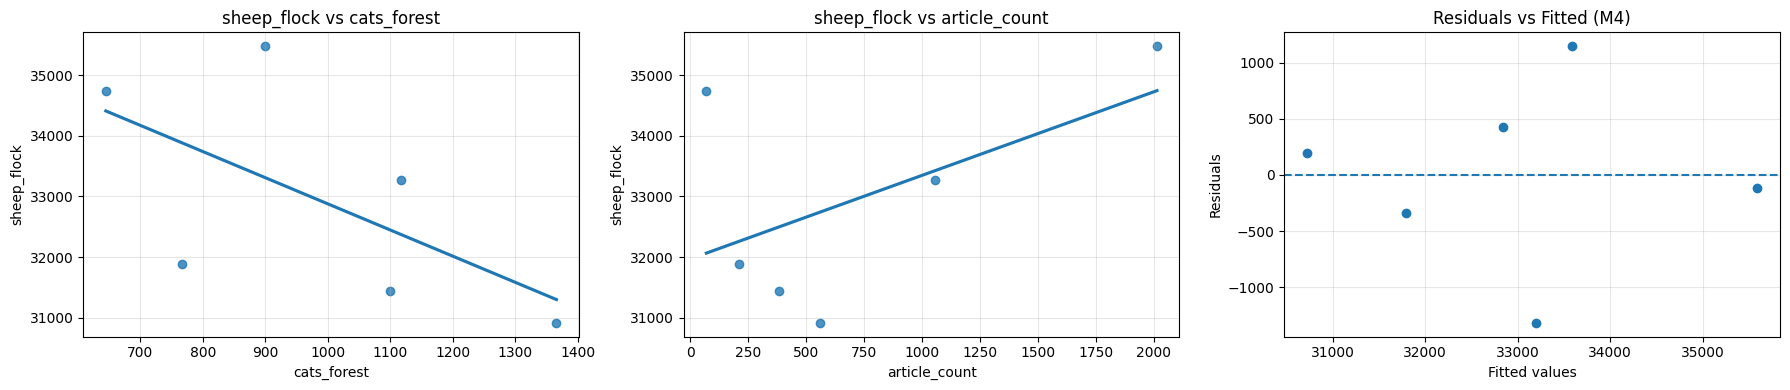

In [42]:
# Linearity

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# sheep_flock vs cats_forest
sns.regplot(
    data=model_df_m4,
    x='cats_forest',
    y='sheep_flock',
    ci=None,
    ax=axes[0]
)
axes[0].set_title('sheep_flock vs cats_forest')
axes[0].grid(alpha=0.3)

# sheep_flock vs article_count
sns.regplot(
    data=model_df_m4,
    x='article_count',
    y='sheep_flock',
    ci=None,
    ax=axes[1]
)
axes[1].set_title('sheep_flock vs article_count')
axes[1].grid(alpha=0.3)

# residuals vs fitted
axes[2].scatter(model_df_m4['fitted'], model_df_m4['residuals'])
axes[2].axhline(0, linestyle='--')
axes[2].set_xlabel('Fitted values')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Residuals vs Fitted (M4)')
axes[2].grid(alpha=0.3)

fig.tight_layout()
plt.show()

The scatterplots suggest approximately linear relationships between `sheep_flock` and both predictors. The residuals-versus-fitted plot does not show a clear nonlinear pattern.

In [43]:
# Independence of errors

dw_stat = durbin_watson(model_m4.resid)

print("Durbin-Watson statistic:", round(dw_stat, 3))

if 1.5 <= dw_stat <= 2.5:
    print("The residuals do not show strong evidence of autocorrelation.")
elif dw_stat < 1.5:
    print("The residuals may exhibit positive autocorrelation.")
else:
    print("The residuals may exhibit negative autocorrelation.")

Durbin-Watson statistic: 2.806
The residuals may exhibit negative autocorrelation.


The Durbin–Watson statistic for Model M4 is **2.806**, which is above 2 and may indicate negative autocorrelation in the residuals.

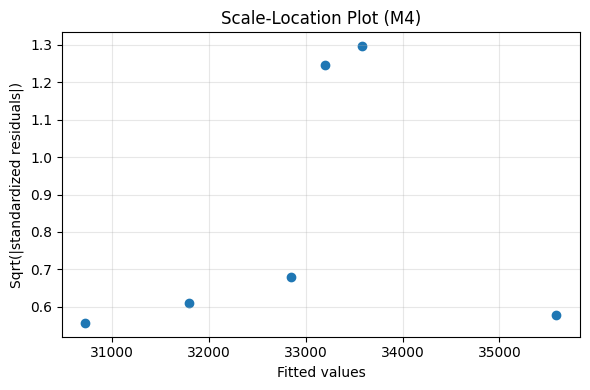

Breusch-Pagan test:
LM statistic: 5.0042
LM p-value: 0.0819
F statistic: 7.5380
F p-value: 0.0676
There is no strong evidence of heteroscedasticity.


In [44]:
# Homoscedasticity

# Standardized residuals
model_df_m4['std_residuals'] = model_m4.get_influence().resid_studentized_internal

# Scale-location plot
plt.figure(figsize=(6, 4))
plt.scatter(model_df_m4['fitted'], np.sqrt(np.abs(model_df_m4['std_residuals'])))
plt.xlabel('Fitted values')
plt.ylabel('Sqrt(|standardized residuals|)')
plt.title('Scale-Location Plot (M4)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Breusch-Pagan test
bp_test = het_breuschpagan(model_m4.resid, model_m4.model.exog)
bp_labels = ['LM statistic', 'LM p-value', 'F statistic', 'F p-value']

print("Breusch-Pagan test:")
for name, value in zip(bp_labels, bp_test):
    print(f"{name}: {value:.4f}")

if bp_test[1] > 0.05:
    print("There is no strong evidence of heteroscedasticity.")
else:
    print("There may be evidence of heteroscedasticity.")

 The visual pattern does not show a perfectly constant spread of residuals, although no strong systematic increase in variance is evident. The Breusch–Pagan test produced p-values of **0.0819** (LM) and **0.0676** (F), which are above the 0.05 threshold. Therefore, there is no strong statistical evidence of heteroscedasticity in Model M4.

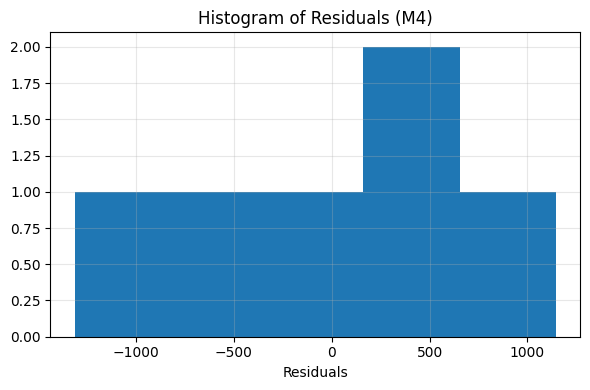

<Figure size 600x400 with 0 Axes>

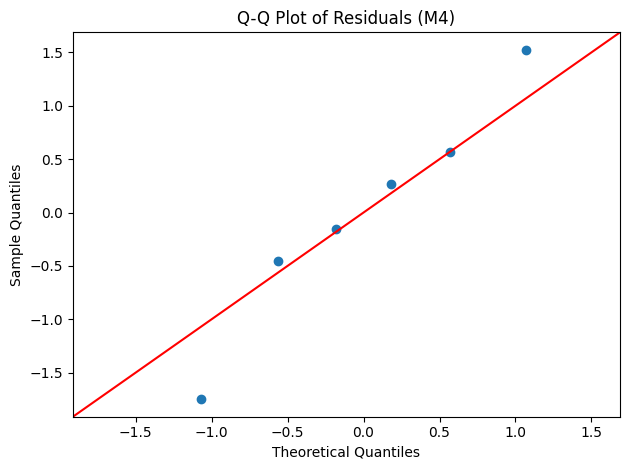

Shapiro-Wilk statistic: 0.9819
Shapiro-Wilk p-value: 0.9606
The residuals do not show strong evidence of non-normality.


In [48]:
#  Normality of residuals

# Histogram of residuals
plt.figure(figsize=(6, 4))
plt.hist(model_df_m4['residuals'], bins=5)
plt.title('Histogram of Residuals (M4)')
plt.xlabel('Residuals')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Q-Q plot
plt.figure(figsize=(6, 4))
sm.qqplot(model_m4.resid, line='45', fit=True)
plt.title('Q-Q Plot of Residuals (M4)')
plt.tight_layout()
plt.show()

# Shapiro-Wilk test
shapiro_stat, shapiro_p = shapiro(model_m4.resid)

print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}")
print(f"Shapiro-Wilk p-value: {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("The residuals do not show strong evidence of non-normality.")
else:
    print("The residuals may deviate from normality.")

The residuals appear approximately symmetric, and the Q-Q plot does not show strong deviations from the reference line. The Shapiro–Wilk test produced a p-value of **0.9606**, which is well above 0.05 (as we 100% expected), nevertheless, indicating no strong evidence against normality.

Overall, the diagnostic checks for Model M4 do not reveal strong violations of the standard linear regression assumptions.  
The relationships between the predictors and the dependent variable appear approximately linear, there is no strong statistical evidence of heteroscedasticity, and the residuals do not show clear departures from normality. The Durbin–Watson statistic suggests possible negative autocorrelation, although this result is difficult to interpret reliably given the extremely small sample size.

Therefore, Model M4 can be used as the main exploratory specification, but all results should be interpreted with substantial caution.

### Main model interpretation

Model M4 (`sheep_flock ~ cats_forest + article_count`) was selected as the main specification because it combines a broad farm outcome with a cat-related indicator and a news-related measure, while also showing one of the strongest model fits among the tested alternatives.

The estimated coefficients suggest that higher feral cat presence in forest areas is associated with a lower sheep flock, whereas greater media attention is associated with a larger sheep flock. Both predictors are close to conventional significance levels, but neither reaches the 0.05 threshold. Given the very small sample size, these findings should be treated only as exploratory rather than conclusive.